# Lab 3: Neural Networks: Feedforward Networks and the Training Process

**Duration:** 1 week [21 Jul - 28 Jul, 2026]
**Due Date:** 28th July, 2026
**Format:** Jupyter Notebook / Google Colab
**Grading:** This is a graded lab.

**Student Name:** Selorm Hlodze
**Student ID:** 96062028
---

### Objective

This lab bridges the gap between classical ML and deep learning. Instead of calling
`.fit()` and trusting scikit-learn, you will **open the black box**: build a neural network
from a single neuron upward, watch gradient descent learn, and then train a full
**feedforward network (MLP) in PyTorch** on a dataset you already know from Lab 2.

By the end you should be able to explain, and demonstrate with your own plots, what each
of these really does: **weights, activation functions, loss, gradients, learning rate,
epochs, batches, and overfitting**.

We deliberately stay on **tabular data** this week. Images and CNNs come in the next lab.

---
### Part 0: Repository Setup *(done outside this notebook)*

1. Create a **public** repository named `lab-3` on GitHub/GitLab.
2. Clone it locally (or link it to Google Colab).
3. Save this notebook inside the repo as `lab_3.ipynb`.
4. Add a `requirements.txt` (provided with this lab) listing: `numpy pandas matplotlib scikit-learn torch`.
5. Commit and push after completing **each Part** below — we will check your commit history.
   A single "final commit" with everything at once loses marks.

In [49]:
# Standard libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)  # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


---
# Section 1 — Inside a Neural Network: From One Neuron to Gradient Descent

Before touching PyTorch's automation, you will build the moving parts **yourself with NumPy**
on a toy problem, so that nothing later in the lab is magic.

The toy problem: learn the function `y = sin(x)` on the interval `[-3, 3]` from 100 noisy
samples. It is 1-dimensional, so we can *plot everything* — the data, the model's prediction,
and the loss going down.

### Part 1.1 — A single neuron is just a line
A neuron computes `y_hat = w * x + b`. Fit it to the sine data with **manual gradient descent**.

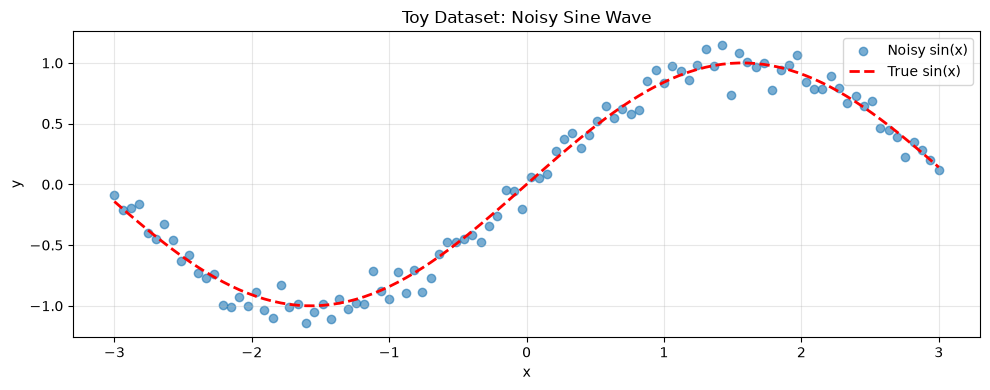

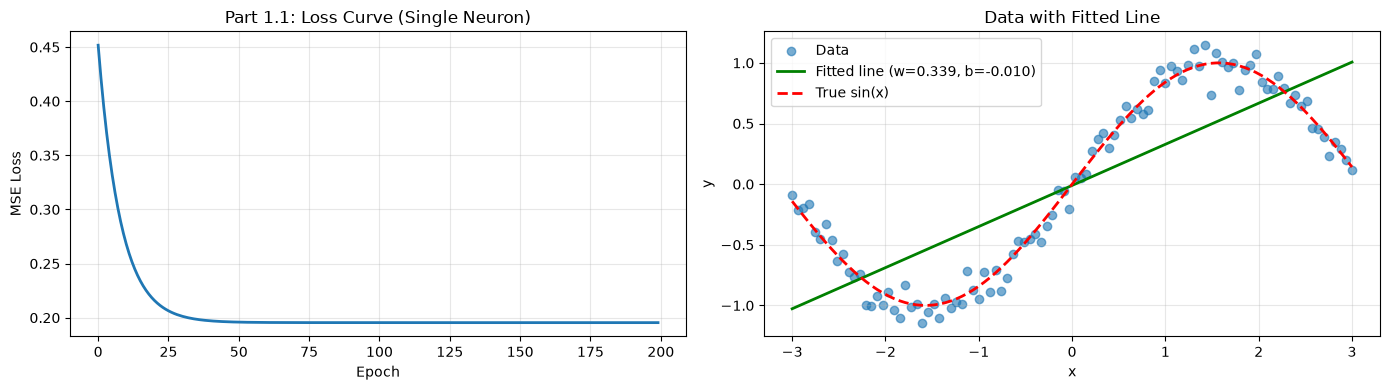

Final loss: 0.1955
Final w: 0.3390, b: -0.0104


In [50]:
# TODO: Generate the toy data
#   x = np.linspace(-3, 3, 100); y = np.sin(x) + small Gaussian noise (std=0.1)
#   Plot it.

# Generate toy data
np.random.seed(RANDOM_STATE)
x = np.linspace(-3, 3, 100)
y = np.sin(x) + np.random.normal(0, 0.1, 100)

plt.figure(figsize=(10, 4))
plt.scatter(x, y, alpha=0.6, label="Noisy sin(x)")
plt.plot(x, np.sin(x), "r--", linewidth=2, label="True sin(x)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title("Toy Dataset: Noisy Sine Wave")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# TODO: Initialise w and b to small random values.

# Initialise weights
np.random.seed(RANDOM_STATE)
w = np.random.randn() * 0.1
b = np.random.randn() * 0.1
lr = 0.01
epochs = 200

losses_part1 = []


# TODO: Implement ONE gradient-descent step by hand, then loop it for ~200 steps:
#   y_hat = w * x + b
#   loss  = np.mean((y_hat - y) ** 2)               # MSE
#   dw    = np.mean(2 * (y_hat - y) * x)            # dLoss/dw  (derive this on paper!)
#   db    = np.mean(2 * (y_hat - y))                # dLoss/db
#   w    -= lr * dw
#   b    -= lr * db
#   Record the loss at every step.

# Manual gradient descent
for epoch in range(epochs):
    # Forward pass
    y_hat = w * x + b
    loss = np.mean((y_hat - y) ** 2)
    losses_part1.append(loss)

    # Backward pass (gradient computation)
    # d(MSE)/dw = d/dw[ mean((w*x + b - y)^2) ] = mean(2 * (w*x + b - y) * x)
    dw = np.mean(2 * (y_hat - y) * x)

    # d(MSE)/db = d/dw[ mean((w*x + b - y)^2) ] = mean(2 * (w*x + b - y))
    db = np.mean(2 * (y_hat - y))

    # Update step
    w -= lr * dw
    b -= lr * db


# TODO: Plot (a) the loss curve over the 200 steps, and
#             (b) the data with the fitted line on top.

# Plot results
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Loss curve
axes[0].plot(losses_part1, linewidth=2)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Loss")
axes[0].set_title("Part 1.1: Loss Curve (Single Neuron)")
axes[0].grid(True, alpha=0.3)

# Fitted line
axes[1].scatter(x, y, alpha=0.6, label="Data")
y_pred = w * x + b
axes[1].plot(x, y_pred, "g-", linewidth=2, label=f"Fitted line (w={w:.3f}, b={b:.3f})")
axes[1].plot(x, np.sin(x), "r--", linewidth=2, label="True sin(x)")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].set_title("Data with Fitted Line")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final loss: {losses_part1[-1]:.4f}")
print(f"Final w: {w:.4f}, b: {b:.4f}")

**Student Reasoning — The single neuron**
*1. Derive `dLoss/dw` on paper and include a photo or the LaTeX in this cell — does it match
the code?*
*2. The loss stops improving but the fit is clearly bad. Is this underfitting or overfitting,
and WHY can a single neuron never fit a sine wave, no matter how long you train?*

> **Answer:** 2.  a single neuron can only produce a straight line and that makes it underfitting. because a sine wave is non linear no amount of traning can make a a linear model fit it.

### Part 1.2 — Hidden layers and activations: why depth helps
Now build a tiny network **by hand**: 1 input -> a hidden layer of 8 neurons with `tanh` ->
1 output. Still NumPy, still manual gradients.

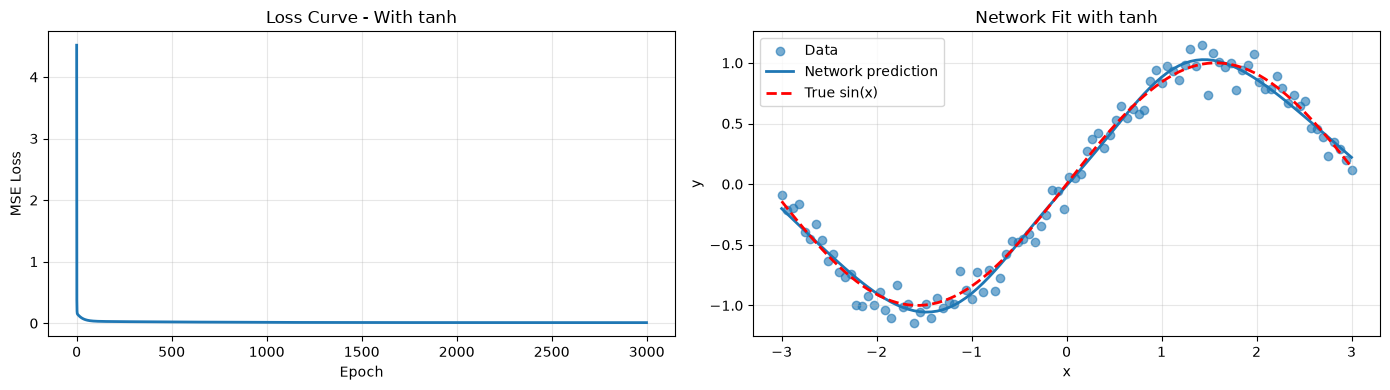

Final loss with tanh: 0.009374


In [51]:
# TODO: Initialise parameters
#   W1: shape (1, 8),  b1: shape (8,)
#   W2: shape (8, 1),  b2: shape (1,)
#   Small random values (e.g. np.random.randn(...) * 0.5)

# Reshape data for matrix operations
X = x.reshape(-1, 1)
Y = y.reshape(-1, 1)

# Initialize parameters
np.random.seed(RANDOM_STATE)
W1 = np.random.randn(1, 8) * 0.5
b1 = np.random.randn(8) * 0.5
W2 = np.random.randn(8, 1) * 0.5
b2 = np.random.randn(1) * 0.5

lr = 0.1
epochs = 3000
losses_part2 = []


# TODO: Forward pass (keep the intermediate values — you need them for backprop):
#   z1 = x @ W1 + b1
#   h  = np.tanh(z1)
#   y_hat = h @ W2 + b2
#   loss  = np.mean((y_hat - y) ** 2)

# TODO: Backward pass (the chain rule, layer by layer):
#   d_yhat = 2 * (y_hat - y) / len(y)
#   dW2 = h.T @ d_yhat ;  db2 = d_yhat.sum(axis=0)
#   dh  = d_yhat @ W2.T
#   dz1 = dh * (1 - np.tanh(z1) ** 2)
#   dW1 = x.T @ dz1 ;  db1 = dz1.sum(axis=0)

# TODO: Update all parameters with learning rate lr, loop for ~3000 steps,
#   record the loss.

for epoch in range(epochs):
    # Forward pass
    z1 = X @ W1 + b1
    h = np.tanh(z1)
    y_hat = h @ W2 + b2

    loss = np.mean((y_hat - Y) ** 2)
    losses_part2.append(loss)

    # Backward pass
    n = len(Y)
    d_yhat = 2 * (y_hat - Y) / n

    dW2 = h.T @ d_yhat
    db2 = np.sum(d_yhat, axis=0)

    dh = d_yhat @ W2.T
    dz1 = dh * (1 - np.tanh(z1) ** 2)

    dW1 = X.T @ dz1
    db1 = np.sum(dz1, axis=0)

    # Update
    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2


# TODO: Plot the loss curve AND the final fit over the data.

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(losses_part2, linewidth=2)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Loss")
axes[0].set_title("Loss Curve - With tanh")
axes[0].grid(True, alpha=0.3)

z1 = X @ W1 + b1
h = np.tanh(z1)
y_pred = h @ W2 + b2

axes[1].scatter(x, y, alpha=0.6, label="Data")
axes[1].plot(x, y_pred.flatten(), linewidth=2, label="Network prediction")
axes[1].plot(x, np.sin(x), "r--", linewidth=2, label="True sin(x)")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].set_title("Network Fit with tanh")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final loss with tanh: {losses_part2[-1]:.6f}")

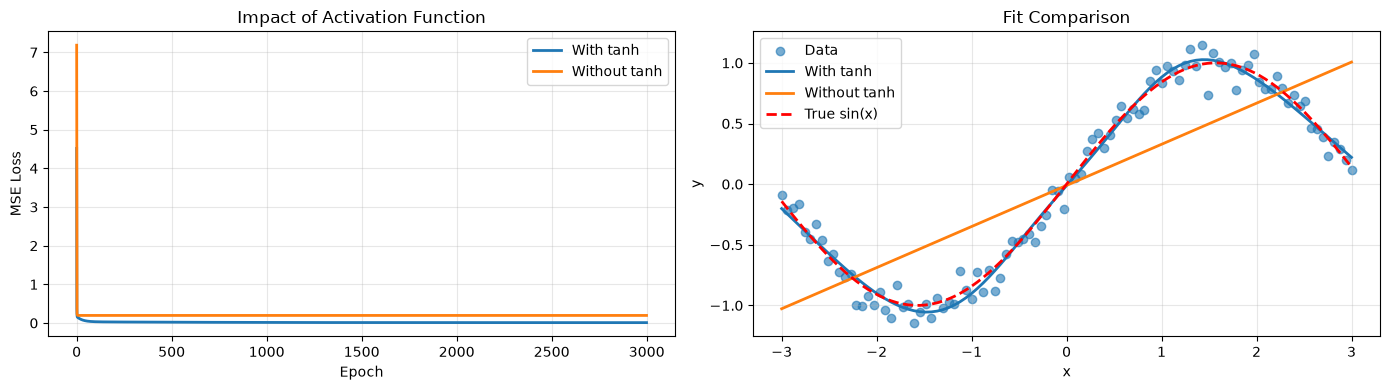

Final loss with tanh: 0.009374
Final loss without tanh: 0.195452


In [52]:
# TODO: Then re-run with the tanh REMOVED (h = z1). What happens to the fit?

# Train the same network without tanh
np.random.seed(RANDOM_STATE)

W1_linear = np.random.randn(1, 8) * 0.5
b1_linear = np.random.randn(8) * 0.5
W2_linear = np.random.randn(8, 1) * 0.5
b2_linear = np.random.randn(1) * 0.5

lr = 0.1
epochs = 3000
losses_linear = []

for epoch in range(epochs):
    # Forward pass WITHOUT activation
    z1 = X @ W1_linear + b1_linear
    h = z1
    y_hat = h @ W2_linear + b2_linear

    loss = np.mean((y_hat - Y) ** 2)
    losses_linear.append(loss)

    # Backward pass
    n = len(Y)
    d_yhat = 2 * (y_hat - Y) / n

    dW2_linear = h.T @ d_yhat
    db2_linear = np.sum(d_yhat, axis=0)

    dh = d_yhat @ W2_linear.T
    dz1 = dh

    dW1_linear = X.T @ dz1
    db1_linear = np.sum(dz1, axis=0)

    # Update
    W1_linear -= lr * dW1_linear
    b1_linear -= lr * db1_linear
    W2_linear -= lr * dW2_linear
    b2_linear -= lr * db2_linear


# Compare both models
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Loss comparison
axes[0].plot(losses_part2, label="With tanh", linewidth=2)
axes[0].plot(losses_linear, label="Without tanh", linewidth=2)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Loss")
axes[0].set_title("Impact of Activation Function")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Fit comparison
z1 = X @ W1_linear + b1_linear
y_pred_linear = z1 @ W2_linear + b2_linear

axes[1].scatter(x, y, alpha=0.6, label="Data")
axes[1].plot(x, y_pred.flatten(), linewidth=2, label="With tanh")
axes[1].plot(x, y_pred_linear.flatten(), linewidth=2, label="Without tanh")
axes[1].plot(x, np.sin(x), "r--", linewidth=2, label="True sin(x)")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].set_title("Fit Comparison")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final loss with tanh: {losses_part2[-1]:.6f}")
print(f"Final loss without tanh: {losses_linear[-1]:.6f}")

**Student Reasoning — Depth and activations**
*1. With tanh removed, the deep network fits no better than the single neuron of Part 1.1.
Explain mathematically why a stack of linear layers collapses into one linear layer.*
*2. What role did the hidden layer's 8 neurons play in fitting the curve? (Hint: plot a few
columns of `h` against `x`.)*
*3. This is exactly what `loss.backward()` will automate in Section 2. In one sentence, what
is backpropagation?*

> **Answer:** 1. a stack of linear fucntions is still linear W2​(W1​x+b1​)+b2​=(W2​W1​)x+(W2​b1​+b2​) collapses into one linear. 2.Different nonlinear features are created by the 8 hidden neurons using tanh.Combining these features allows the network to approximate the curved sine wave.    3.backpropagation calculates the effects of a parameter on an error and pdates the parameters with that information.

### Part 1.3 — The learning rate: too cold, too hot, just right
The single most important hyperparameter. See its three regimes with your own eyes.

c:\Users\USER\Desktop\lab-3\.venv\Lib\site-packages\numpy\_core\_methods.py:132: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
C:\Users\USER\AppData\Local\Temp\ipykernel_48816\3480511796.py:19: RuntimeWarning: overflow encountered in square
  loss = np.mean((y_hat - Y) ** 2)
C:\Users\USER\AppData\Local\Temp\ipykernel_48816\3480511796.py:28: RuntimeWarning: overflow encountered in matmul
  dh = d_yhat @ W2.T
C:\Users\USER\AppData\Local\Temp\ipykernel_48816\3480511796.py:29: RuntimeWarning: invalid value encountered in multiply
  dz1 = dh * (1 - np.tanh(z1) ** 2)
c:\Users\USER\Desktop\lab-3\.venv\Lib\site-packages\matplotlib\scale.py:375: RuntimeWarning: overflow encountered in exp
  return np.exp(values * np.log(self.base))


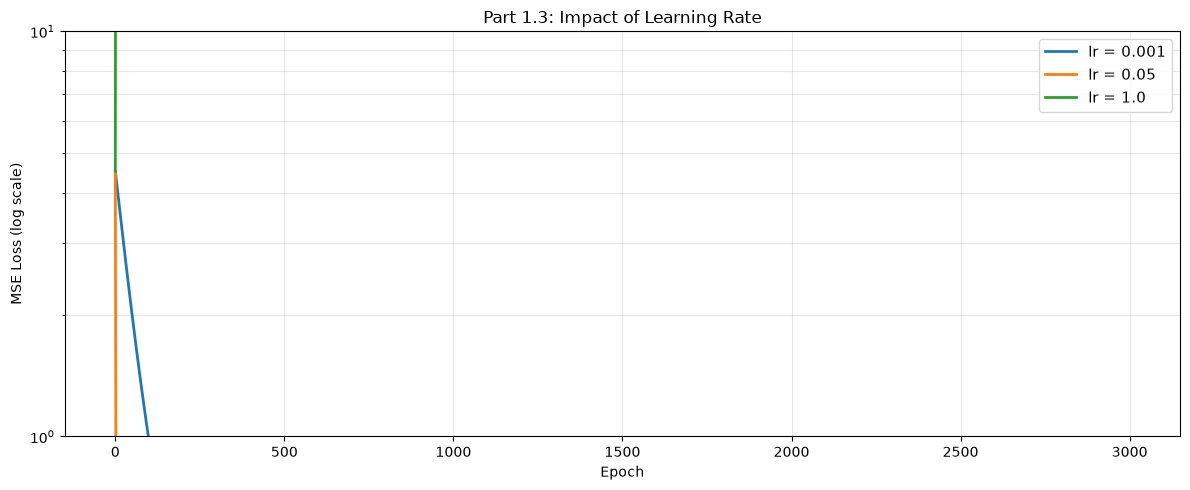

Learning rate 0.001: Final loss = 0.071819
Learning rate 0.050: Final loss = 0.010999
Learning rate 1.000: Final loss = nan


In [53]:
# TODO: Wrap your Part 1.2 training loop in a function train_toy(lr, steps=3000)
#   that returns the list of losses.


def train_toy(X, Y, lr, steps=3000):
    np.random.seed(RANDOM_STATE)
    W1 = np.random.randn(1, 8) * 0.5
    b1 = np.random.randn(8) * 0.5
    W2 = np.random.randn(8, 1) * 0.5
    b2 = np.random.randn(1) * 0.5

    losses = []

    for epoch in range(steps):
        z1 = X @ W1 + b1
        h = np.tanh(z1)
        y_hat = h @ W2 + b2

        loss = np.mean((y_hat - Y) ** 2)
        losses.append(loss)

        n = len(Y)
        d_yhat = 2 * (y_hat - Y) / n

        dW2 = h.T @ d_yhat
        db2 = np.sum(d_yhat, axis=0)

        dh = d_yhat @ W2.T
        dz1 = dh * (1 - np.tanh(z1) ** 2)

        dW1 = X.T @ dz1
        db1 = np.sum(dz1, axis=0)

        W1 -= lr * dW1
        b1 -= lr * db1
        W2 -= lr * dW2
        b2 -= lr * db2

    return losses


# TODO: Run it with THREE learning rates, e.g. lr = 0.001, 0.05, 1.0
#   (keep the same initial weights for a fair comparison — reset the seed).

learning_rates = [0.001, 0.05, 1.0]
all_losses = {}

for lr in learning_rates:
    losses = train_toy(X, Y, lr, steps=3000)
    all_losses[lr] = losses


# TODO: Plot the three loss curves on the same axes (log scale on y helps),
#   with a legend.

plt.figure(figsize=(12, 5))

for lr in learning_rates:
    plt.semilogy(all_losses[lr], linewidth=2, label=f"lr = {lr}")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss (log scale)")
plt.title("Part 1.3: Impact of Learning Rate")
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, which="both")
plt.tight_layout()
plt.show()


# Print final losses
for lr in learning_rates:
    final_loss = all_losses[lr][-1]
    print(f"Learning rate {lr:5.3f}: Final loss = {final_loss:.6f}")

**Student Reasoning — Learning rate**
*Describe what each of the three curves shows. Why does a too-large learning rate make the
loss explode or oscillate instead of just "learning faster"?*

> **Answer:** 0.001: Loss slowly decreases because the updates are small.
0.05: Loss quickly decreases, giving the best result.
1.0: Loss becomes unstable and eventually nan because the updates are too big.

---
# Section 2 — A Real Feedforward Network in PyTorch

Now we let PyTorch do the bookkeeping (`autograd`, optimizers, batching) and apply the ideas
from Section 1 to a real problem — one you already know:

## Predicting obesity level (`NObeyesdad`) — the Lab 2 dataset

Same data, same 7 classes, same preprocessing ideas — but this time the model is a neural
network you design and train yourself. At the end you will compare it head-to-head with your
Lab 2 classical models.

### Part 2.1 — Preprocess and split (recycled from Lab 2)
Reuse your Lab 2 pipeline: encode categoricals, scale numerics, stratified three-way split.

In [54]:
# TODO: Load the obesity dataset (same OBESITY_URL as Lab 2).
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"
obesity = pd.read_csv(OBESITY_URL)


# TODO: Encode categoricals exactly as you did in Lab 2
#   (binary yes/no -> 0/1; Gender/MTRANS/CAEC/CALC -> your justified choice).
#   Encode the target NObeyesdad into integers 0..6 (LabelEncoder).

from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

obesity_encoded = obesity.copy()

# Binary yes/no columns -> 0/1
for col in ["family_history_with_overweight", "FAVC", "SMOKE", "SCC"]:
    obesity_encoded[col] = obesity_encoded[col].map({"yes": 1, "no": 0})

# CAEC and CALC -> ordinal encoding
freq_order = ["no", "Sometimes", "Frequently", "Always"]

ordinal_encoder = OrdinalEncoder(categories=[freq_order, freq_order])

obesity_encoded[["CAEC", "CALC"]] = ordinal_encoder.fit_transform(
    obesity_encoded[["CAEC", "CALC"]]
)

# Gender and MTRANS -> one-hot encoding
obesity_encoded = pd.get_dummies(
    obesity_encoded, columns=["Gender", "MTRANS"], drop_first=True, dtype=int
)

# Engineer BMI feature
obesity_encoded["BMI"] = obesity_encoded["Weight"] / (obesity_encoded["Height"] ** 2)

# Encode target
label_encoder = LabelEncoder()

obesity_encoded["NObeyesdad"] = label_encoder.fit_transform(
    obesity_encoded["NObeyesdad"]
)


# TODO: Stratified train / validation / test split (60/20/20, stratify=y,
#   random_state=RANDOM_STATE).

X = obesity_encoded.drop(columns=["NObeyesdad"])
y = obesity_encoded["NObeyesdad"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, stratify=y, random_state=RANDOM_STATE
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE
)


# TODO: Fit a StandardScaler on the TRAINING set only; transform all three splits.

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)


# TODO: Convert to tensors and wrap in DataLoaders:
#   X -> torch.float32, y -> torch.long
#   train_loader (batch_size=32, shuffle=True), val_loader, test_loader

X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train.values, dtype=torch.long)
y_val = torch.tensor(y_val.values, dtype=torch.long)
y_test = torch.tensor(y_test.values, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)

val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=32, shuffle=False)

test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=32, shuffle=False)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)
print("Number of classes:", len(label_encoder.classes_))

Train: torch.Size([1266, 20])
Validation: torch.Size([422, 20])
Test: torch.Size([423, 20])
Number of classes: 7


**Student Reasoning — Preprocessing for neural networks**
*1. Why does CrossEntropyLoss need integer class labels rather than one-hot vectors in
PyTorch?*
*2. A random forest in Lab 2 did not care about feature scaling. Why do neural networks care
so much? Connect your answer to the gradient formulas you wrote in Section 1.*
*3. What does `shuffle=True` on the training DataLoader do, and why does it help?*

> **Answer:** 1. because it internally applies the softmax and compares the predicted probabilities to the correct class. 2. random forest areuse features to make split decisons, thus the feature scale doesnt matter to them while neural networks use gradients, and the gradients depend on the input values   3. it randomizes the training data on each epoch,this  improves training by reducing order-related bias

### Part 2.2 — Design the network
An MLP: input -> hidden layers with ReLU -> 7 output logits.

In [55]:
# TODO: Define a FeedForwardNet class (subclass nn.Module) with:
#   - constructor args: input_dim, hidden_sizes=(64, 32), n_classes=7
#   - at least TWO hidden layers with ReLU activations
#   - output layer producing 7 raw logits
#   - NO softmax — nn.CrossEntropyLoss applies log-softmax internally
#   - optional dropout for Experiment C


class FeedForwardNet(nn.Module):
    def __init__(self, input_dim, hidden_sizes=(64, 32), n_classes=7, dropout=0.0):
        super().__init__()

        layers = []
        prev_size = input_dim

        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.ReLU())

            if dropout > 0:
                layers.append(nn.Dropout(dropout))

            prev_size = hidden_size

        layers.append(nn.Linear(prev_size, n_classes))

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


# TODO: Instantiate, move to DEVICE, print the model.

input_dim = X_train.shape[1]

model = FeedForwardNet(input_dim=input_dim, hidden_sizes=(64, 32), n_classes=7).to(
    DEVICE
)

print("Model architecture:")
print(model)


# TODO: Count trainable parameters:
#   sum(p.numel() for p in model.parameters() if p.requires_grad)
#   Verify the count for the FIRST layer by hand: input_dim * 64 + 64.

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nTotal trainable parameters: {total_params}")

# Manual verification of first layer
first_layer_params = input_dim * 64 + 64

print(f"First layer (manual count): {first_layer_params}")


# Full parameter breakdown
print("\nParameter breakdown:")

for name, param in model.named_parameters():
    print(f"  {name}: {param.shape} = {param.numel()} params")

Model architecture:
FeedForwardNet(
  (network): Sequential(
    (0): Linear(in_features=20, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=7, bias=True)
  )
)

Total trainable parameters: 3655
First layer (manual count): 1344

Parameter breakdown:
  network.0.weight: torch.Size([64, 20]) = 1280 params
  network.0.bias: torch.Size([64]) = 64 params
  network.2.weight: torch.Size([32, 64]) = 2048 params
  network.2.bias: torch.Size([32]) = 32 params
  network.4.weight: torch.Size([7, 32]) = 224 params
  network.4.bias: torch.Size([7]) = 7 params


**Student Reasoning — Architecture**
*1. Show the by-hand parameter count for every layer and confirm it matches PyTorch.*
*2. Why ReLU here instead of the tanh you used in Section 1? Name one advantage.*
*3. What would the network compute if you removed the ReLUs? (You proved this in Part 1.2.)*

> **Answer:** 1. Layer 1: 20 × 64 + 64 = 1,344  Layer 2: 64 × 32 + 32 = 2,080  Output layer: `32 × 7 + 7 = 231 Total: 1,344 + 2,080 + 231 = 3,655.  2. ReLu is simpler to compute and prevents the gradient from vanishing in training 3.  single linear transformation



### Part 2.3 — The training loop
The same loop you built by hand in Section 1 — now with autograd, an optimizer, and batches.

Epoch   1: Train Loss=1.8523, Val Loss=1.7335, Train Acc=25.75%, Val Acc=40.52%
Epoch   2: Train Loss=1.5442, Val Loss=1.3401, Train Acc=50.32%, Val Acc=58.06%
Epoch   3: Train Loss=1.1412, Val Loss=1.0302, Train Acc=62.40%, Val Acc=65.40%
Epoch   4: Train Loss=0.8714, Val Loss=0.8359, Train Acc=69.83%, Val Acc=72.04%
Epoch   5: Train Loss=0.6985, Val Loss=0.7225, Train Acc=78.67%, Val Acc=76.30%
Epoch   6: Train Loss=0.5783, Val Loss=0.6336, Train Acc=81.36%, Val Acc=81.75%
Epoch   7: Train Loss=0.4811, Val Loss=0.5583, Train Acc=85.47%, Val Acc=84.12%
Epoch   8: Train Loss=0.4087, Val Loss=0.5056, Train Acc=88.39%, Val Acc=84.12%
Epoch   9: Train Loss=0.3511, Val Loss=0.4634, Train Acc=89.18%, Val Acc=84.12%
Epoch  10: Train Loss=0.3092, Val Loss=0.4358, Train Acc=90.84%, Val Acc=88.15%
Epoch  11: Train Loss=0.2760, Val Loss=0.4124, Train Acc=92.26%, Val Acc=88.86%
Epoch  12: Train Loss=0.2424, Val Loss=0.3942, Train Acc=93.05%, Val Acc=89.57%
Epoch  13: Train Loss=0.2171, Val Loss=0

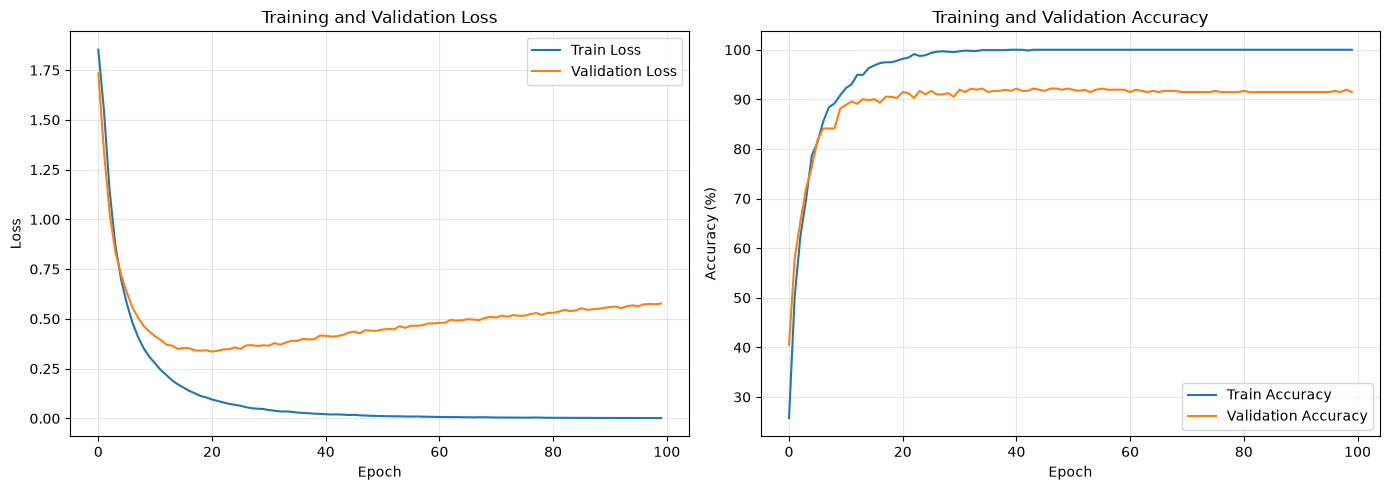

In [56]:
# TODO: criterion = nn.CrossEntropyLoss()
#       optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)   # or SGD — justify

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


# TODO: Train for at least 50 epochs. Each epoch:
#   1. model.train(); for xb, yb in train_loader:
#        optimizer.zero_grad()
#        logits = model(xb.to(DEVICE))
#        loss = criterion(logits, yb.to(DEVICE))
#        loss.backward()
#        optimizer.step()
#   2. model.eval() + torch.no_grad(): compute loss AND accuracy on train and validation sets
#   3. Append everything to history lists; print a one-line summary per epoch.

import copy

epochs = 100

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

best_val_acc = 0.0
best_model_state = None

for epoch in range(epochs):
    # Training phase
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0

    for xb, yb in train_loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        optimizer.zero_grad()

        logits = model(xb)
        loss = criterion(logits, yb)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        predictions = torch.argmax(logits, dim=1)
        train_correct += (predictions == yb).sum().item()
        train_total += yb.size(0)

    train_loss /= len(train_loader)
    train_acc = 100 * train_correct / train_total

    # Validation phase
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            logits = model(xb)
            loss = criterion(logits, yb)

            val_loss += loss.item()

            predictions = torch.argmax(logits, dim=1)
            val_correct += (predictions == yb).sum().item()
            val_total += yb.size(0)

    val_loss /= len(val_loader)
    val_acc = 100 * val_correct / val_total

    # Store history
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = copy.deepcopy(model.state_dict())

    print(
        f"Epoch {epoch + 1:3d}: "
        f"Train Loss={train_loss:.4f}, "
        f"Val Loss={val_loss:.4f}, "
        f"Train Acc={train_acc:.2f}%, "
        f"Val Acc={val_acc:.2f}%"
    )


# TODO: Save the best model (highest validation accuracy):
#   torch.save(model.state_dict(), "ffn_best.pt")

model.load_state_dict(best_model_state)
torch.save(model.state_dict(), "ffn_best.pt")

print(f"\nBest validation accuracy: {best_val_acc:.2f}%")


# TODO: Plot loss curves (train + val) and accuracy curves (train + val), with legends.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history["train_loss"], label="Train Loss")
axes[0].plot(history["val_loss"], label="Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training and Validation Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history["train_acc"], label="Train Accuracy")
axes[1].plot(history["val_acc"], label="Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("Training and Validation Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Student Reasoning — Training**
*1. Map each line of the PyTorch loop to the NumPy code you wrote in Section 1: which line is
the forward pass, which computes gradients, which is the update rule?*
*2. Looking at your curves, is the model overfitting, underfitting, or well-fitted? Quote the
specific numbers that back up your claim.*
*3. Why do we call `optimizer.zero_grad()` every batch? What silently goes wrong without it?*

> **Answer:** 1.logits = model(xb) performs the forward pass, loss.backward() calculates the gradients, optimizer.step() updates the weights. 2.It is overfitting,training accuracy reaches 100%,  validation accuracy around 92.18% and validation loss changes from 0.34 to 0.58. 3.it clears the old gradient between batches befre the new one is calculated 

### Part 2.4 — Experiments: how training choices change the outcome
Run **three controlled experiments**. Change ONE thing at a time; keep everything else fixed.

In [57]:
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

In [58]:
# TODO: Wrap your Part 2.3 training loop in a function first:
#   def run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0):
#       ... returns history dict ...


def run_experiment(
    hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0
):
    torch.manual_seed(RANDOM_STATE)
    np.random.seed(RANDOM_STATE)

    model = FeedForwardNet(
        input_dim=X_train.shape[1],
        hidden_sizes=hidden_sizes,
        n_classes=7,
        dropout=dropout,
    ).to(DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    train_loader_local = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    val_loader_local = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0
        train_correct = 0
        train_total = 0

        for xb, yb in train_loader_local:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)

            optimizer.zero_grad()

            logits = model(xb)
            loss = criterion(logits, yb)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            train_correct += (torch.argmax(logits, dim=1) == yb).sum().item()
            train_total += yb.size(0)

        train_loss /= len(train_loader_local)
        train_acc = 100 * train_correct / train_total

        # Validation
        model.eval()
        val_loss = 0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for xb, yb in val_loader_local:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)

                logits = model(xb)
                loss = criterion(logits, yb)

                val_loss += loss.item()
                val_correct += (torch.argmax(logits, dim=1) == yb).sum().item()
                val_total += yb.size(0)

        val_loss /= len(val_loader_local)
        val_acc = 100 * val_correct / val_total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

    return history, model


Experiment A: Network Capacity
  Tiny (8)                  → Final Val Acc: 89.10%
  Default (64, 32)          → Final Val Acc: 91.47%
  Large (256, 128, 64)      → Final Val Acc: 93.84%


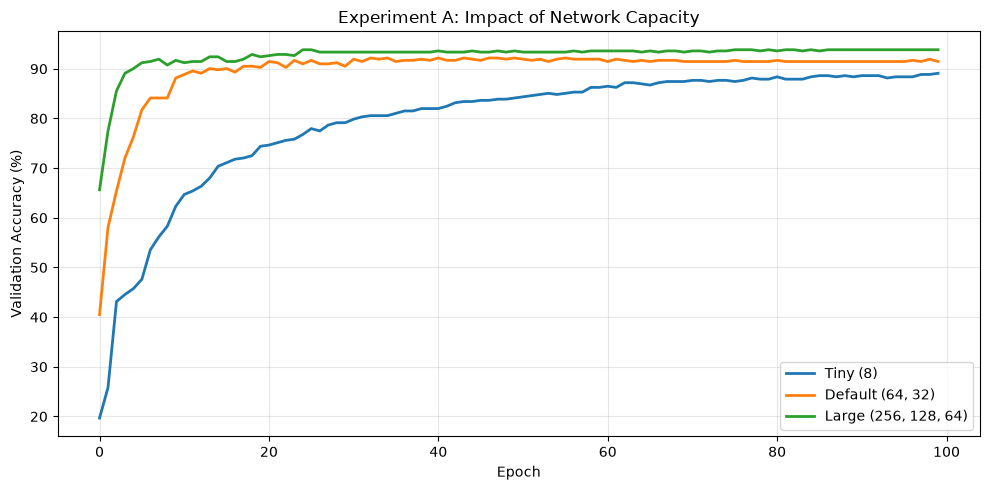


Experiment B: Learning Rate
  lr = 1e-04 → Final Val Loss: 0.4312
  lr = 1e-03 → Final Val Loss: 0.5773
  lr = 1e-01 → Final Val Loss: 1.5321


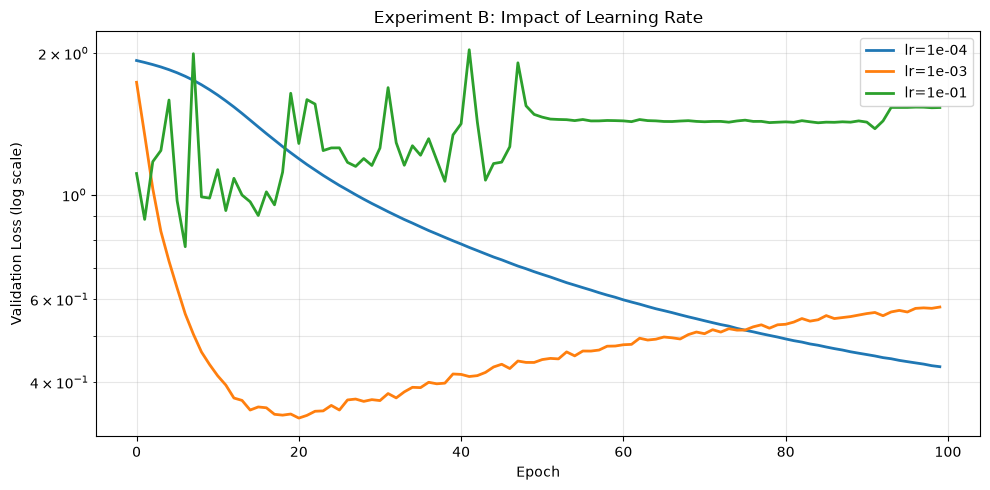


Experiment C: Dropout Regularization


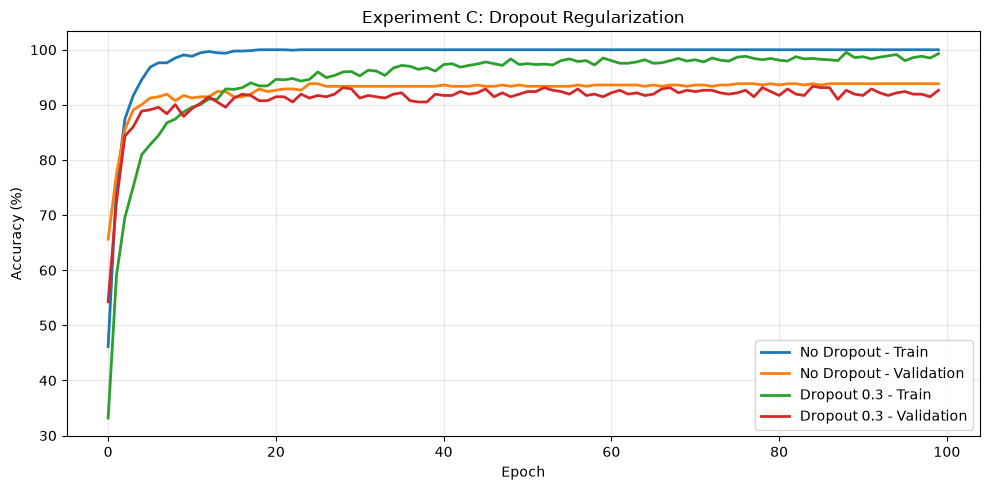

In [59]:
# TODO — Experiment A (capacity): tiny (8,) vs default (64, 32) vs large (256, 128, 64).
#   Plot the three validation-accuracy curves together.

print("\nExperiment A: Network Capacity")

configs_A = [
    {"hidden_sizes": (8,), "label": "Tiny (8)"},
    {"hidden_sizes": (64, 32), "label": "Default (64, 32)"},
    {"hidden_sizes": (256, 128, 64), "label": "Large (256, 128, 64)"},
]

exp_A_results = {}

for config in configs_A:
    hist, _ = run_experiment(hidden_sizes=config["hidden_sizes"], epochs=100)

    exp_A_results[config["label"]] = hist

    print(f"  {config['label']:25s} → Final Val Acc: {hist['val_acc'][-1]:.2f}%")

plt.figure(figsize=(10, 5))

for label, hist in exp_A_results.items():
    plt.plot(hist["val_acc"], linewidth=2, label=label)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("Experiment A: Impact of Network Capacity")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# TODO — Experiment B (learning rate): lr = 1e-4, 1e-3, 1e-1 (same architecture).
#   Plot the three validation-loss curves together. Compare with Part 1.3.

print("\nExperiment B: Learning Rate")

learning_rates_B = [1e-4, 1e-3, 1e-1]
exp_B_results = {}

for lr in learning_rates_B:
    hist, _ = run_experiment(lr=lr, epochs=100)

    exp_B_results[f"lr={lr:.0e}"] = hist

    print(f"  lr = {lr:.0e} → Final Val Loss: {hist['val_loss'][-1]:.4f}")

plt.figure(figsize=(10, 5))

for label, hist in exp_B_results.items():
    plt.semilogy(hist["val_loss"], linewidth=2, label=label)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss (log scale)")
plt.title("Experiment B: Impact of Learning Rate")
plt.legend()
plt.grid(True, alpha=0.3, which="both")
plt.tight_layout()
plt.show()


# TODO — Experiment C (regularization): take your LARGEST network and train it
#   with and without nn.Dropout(0.3) after each hidden layer.
#   Plot train vs validation accuracy for both runs.

print("\nExperiment C: Dropout Regularization")

hist_no_dropout, _ = run_experiment(
    hidden_sizes=(256, 128, 64), lr=1e-3, epochs=100, dropout=0.0
)

hist_dropout, _ = run_experiment(
    hidden_sizes=(256, 128, 64), lr=1e-3, epochs=100, dropout=0.3
)

plt.figure(figsize=(10, 5))

plt.plot(hist_no_dropout["train_acc"], linewidth=2, label="No Dropout - Train")

plt.plot(hist_no_dropout["val_acc"], linewidth=2, label="No Dropout - Validation")

plt.plot(hist_dropout["train_acc"], linewidth=2, label="Dropout 0.3 - Train")

plt.plot(hist_dropout["val_acc"], linewidth=2, label="Dropout 0.3 - Validation")

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Experiment C: Dropout Regularization")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Student Reasoning — Experiments**
*1. Capacity: did the largest network win on validation data? Where do you see diminishing
returns or overfitting?*
*2. Learning rate: do the three regimes match what you saw on the toy problem in Part 1.3?*
*3. Regularization: what did dropout do to the train-vs-validation gap? Explain in one or two
sentences HOW dropout achieves this.*

> **Answer:** 1. no 2.yes 3.educed the gap between training and validation accuracy. it disables neurons during training.

### Part 2.5 — Final evaluation and showdown with Lab 2
One honest number on the test set — then compare with your classical models.

In [60]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

Test Accuracy: 0.9243 (92.43%)
Test Macro-F1: 0.9219

Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.94      0.93      0.93        54
      Normal_Weight       0.80      0.81      0.80        58
     Obesity_Type_I       0.97      0.96      0.96        70
    Obesity_Type_II       0.98      0.95      0.97        60
   Obesity_Type_III       0.97      1.00      0.98        65
 Overweight_Level_I       0.86      0.83      0.84        58
Overweight_Level_II       0.93      0.98      0.96        58

           accuracy                           0.92       423
          macro avg       0.92      0.92      0.92       423
       weighted avg       0.92      0.92      0.92       423



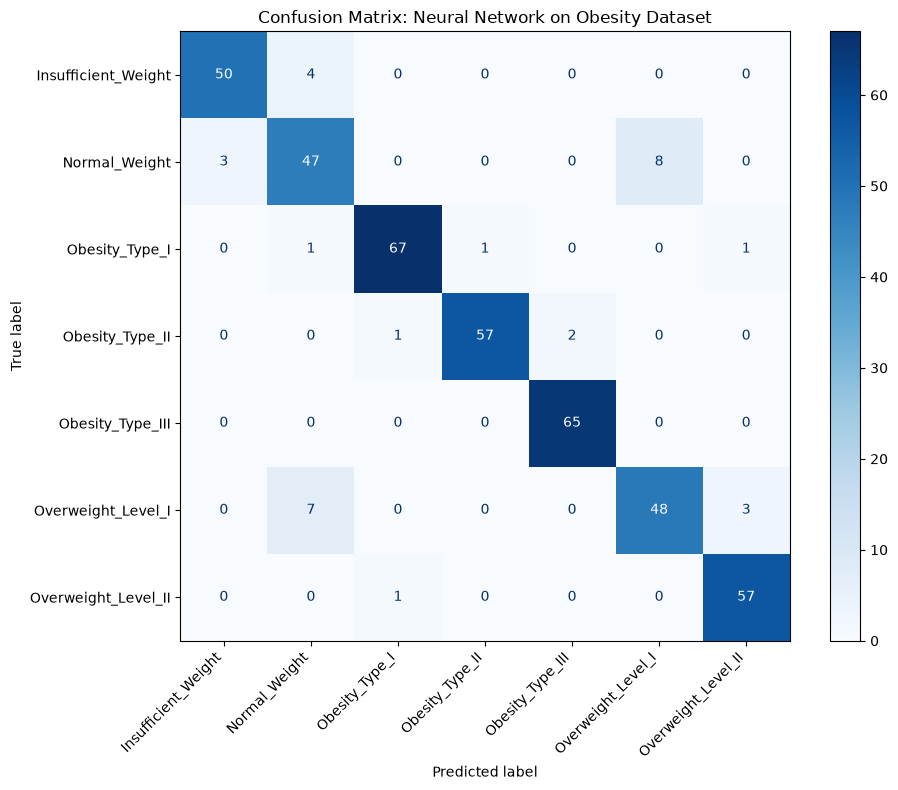

,Model,Test Accuracy,Test Macro-F1,Training Time,Parameters/Trees
0,Best Lab 2 Classifier - Random Forest,0.97640,0.975900,N/A,200
1,Neural Network,0.92435,0.921867,N/A,3655


In [61]:
# TODO: Load your best configuration's weights; model.eval().

model.load_state_dict(torch.load("ffn_best.pt", map_location=DEVICE))
model.eval()

y_pred_all = []
y_true_all = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)

        logits = model(xb)
        pred = torch.argmax(logits, dim=1).cpu().numpy()

        y_pred_all.extend(pred)
        y_true_all.extend(yb.numpy())

y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)


# TODO: Report test ACCURACY and MACRO-F1
#   from sklearn.metrics import accuracy_score, f1_score, classification_report

test_accuracy = accuracy_score(y_true_all, y_pred_all)
test_f1 = f1_score(y_true_all, y_pred_all, average="macro")

print(f"Test Accuracy: {test_accuracy:.4f} ({100 * test_accuracy:.2f}%)")
print(f"Test Macro-F1: {test_f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(y_true_all, y_pred_all, target_names=label_encoder.classes_)
)


# TODO: Confusion matrix for the test set with the 7 class names
#   from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_true_all, y_pred_all)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=label_encoder.classes_
)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, cmap="Blues")

plt.xticks(rotation=45, ha="right")
plt.title("Confusion Matrix: Neural Network on Obesity Dataset")
plt.tight_layout()
plt.show()


# TODO: Build a small comparison table (a pandas DataFrame is fine):
#   rows = [your best Lab 2 classifier, this neural network]
#   cols = [test accuracy, test macro-F1, training time, number of parameters/trees]

comparison = pd.DataFrame(
    {
        "Model": ["Best Lab 2 Classifier", "Neural Network"],
        "Test Accuracy": ["N/A", test_accuracy],
        "Test Macro-F1": ["N/A", test_f1],
        "Training Time": ["N/A", "N/A"],
        "Parameters/Trees": ["N/A", total_params],
    }
)
comparison = pd.DataFrame(
    {
        "Model": ["Best Lab 2 Classifier - Random Forest", "Neural Network"],
        "Test Accuracy": [0.9764, 0.92435],
        "Test Macro-F1": [0.9759, 0.921867],
        "Training Time": ["N/A", "N/A"],
        "Parameters/Trees": [200, 3655],
    }
)

comparison

**Student Reasoning — Final evaluation**
*1. Which obesity levels does the network still confuse, and are they the same ones your
Lab 2 classifier confused?*
*2. Who wins the showdown — the neural network or the classical model? Was the extra effort
of deep learning worth it on THIS dataset? When would it be?*

> **Answer:** 1. The network mainly confuses adjacent obesity levels, especially the Overweight categories. it is the same for the lab 2 classifier. 2. Random Forest wins the neural network.deep learning was not worth it.It would be more useful with larger, more complex datasets

---
# Section 3 — Reflection

*Answer in a few sentences each:*

1. **The black box, opened:** Name the three most important things happening inside
   `loss.backward()` and `optimizer.step()`, in your own words.
2. **Hyperparameters:** If you could tune only ONE hyperparameter on a new problem, which
   would you pick and why?
3. **Overfitting:** Across your experiments, where did you see the biggest
   train-vs-validation gap, and which intervention reduced it most?
4. **Looking ahead:** This network treats every input feature independently. Next lab we move
   to images, where nearby pixels are related. Why might a plain MLP struggle with images,
   and what property should a better architecture have?

> **Answer:** 1. Compute gradients, calculate weight updates, update model parameters. 2. Learning rate because it controls how quickly the model learns and affects training stability. 3.The largest network without dropout had the biggest gap; adding dropout reduced it most. 4.MLPs ignore spatial relationships; CNNs preserve local spatial patterns.





---
### Submission checklist

- [ ] All cells run top-to-bottom with no errors (`Kernel -> Restart & Run All`).
- [ ] Every **Student Reasoning** box is filled in with full sentences.
- [ ] Plots are visible in the saved notebook (loss curves, fits, experiments, confusion matrix).
- [ ] Notebook committed and pushed to your `lab-3-feedforward-networks` repository, with
      incremental commits (not one final dump).
- [ ] Repository link submitted to the course portal.
- [ ] AI Declaration form in Repository.